# Extension 1: Churn Prediction

**Goal:** Predict which active users will stop using the app within 30 days.

**Model:** `GBTClassifier` via Spark MLlib `Pipeline`

**Data sources:**
| Table | Role |
|---|---|
| `session_metrics` | Per-session behavioral features |
| `user_metadata` | User profile features |

**Feasibility signal:** AUC-ROC > 0.70 confirms meaningful churn signal in existing features.

---
**Prerequisites:** Run `make run-jobs` (or `make quickstart`) before opening this notebook.
All 13 PostgreSQL tables must be populated.

## Cell 1 — Setup

In [1]:
import os
import pandas as pd
import psycopg2
from pyspark.sql import SparkSession

PG = dict(
    host=os.getenv("POSTGRES_HOST", "postgres"),
    port=int(os.getenv("POSTGRES_PORT", 5432)),
    dbname=os.getenv("POSTGRES_DB", "analytics"),
    user=os.getenv("POSTGRES_USER", "analytics_user"),
    password=os.getenv("POSTGRES_PASSWORD", "analytics_pass"),
)

def pg_query(sql: str) -> pd.DataFrame:
    """Execute SQL and return a pandas DataFrame."""
    # psycopg2's context manager only manages transactions (commit/rollback),
    # NOT the connection lifecycle — close() must be called explicitly.
    conn = psycopg2.connect(**PG)
    try:
        return pd.read_sql(sql, conn)
    finally:
        conn.close()

# Connect to the existing Spark cluster.
# spark.driver.host must be set to the Jupyter container hostname so that
# spark-worker-1 and spark-worker-2 can open the callback channel to the driver.
spark = (
    SparkSession.builder
    .appName("ML Feasibility — Churn Prediction")
    .master(os.getenv("SPARK_MASTER_URL", "spark://spark-master:7077"))
    .config("spark.driver.host", "goodnote-jupyter")
    .config("spark.driver.bindAddress", "0.0.0.0")
    .config("spark.driver.memory", "2g")
    .config("spark.executor.memory", "2g")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")
print("Spark", spark.version, "master:", spark.sparkContext.master)

Spark 3.5.0 master: local[*]


## Cell 2 — Feature Engineering

Aggregate per-user session behavior and join with profile metadata.
The churn label is derived from recency: users inactive for > 30 days are labelled churned.

In [2]:
df = pg_query("""
    SELECT
        s.user_id,
        COUNT(*)                                   AS total_sessions,
        AVG(s.session_duration_ms) / 1000.0        AS avg_session_sec,
        AVG(s.actions_count)                       AS avg_actions_per_session,
        SUM(s.is_bounce)::float / COUNT(*)         AS personal_bounce_rate,
        MAX(s.session_start_time)                  AS last_seen,
        m.device_type,
        m.country,
        m.subscription_type
    FROM session_metrics s
    JOIN user_metadata m USING (user_id)
    GROUP BY s.user_id, m.device_type, m.country, m.subscription_type
""")

print(f"Users loaded: {len(df):,}")
df.head()

Users loaded: 9,709


/tmp/ipykernel_15502/181798453.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn)


,user_id,total_sessions,avg_session_sec,avg_actions_per_session,personal_bounce_rate,last_seen,device_type,country,subscription_type
0,user_004085,1,0.846,1.0,1.0,2024-09-07 19:30:39,Android Phone,UK,free
1,user_002963,1,146.641,6.0,0.0,2024-07-15 09:03:26,Android Phone,US,free
2,user_006777,1,0.479,1.0,1.0,2024-07-08 11:18:20,iPhone,AU,free
3,user_008585,1,21.846,3.0,0.0,2024-08-31 12:24:22,iPhone,US,free
4,user_002215,1,25.542,3.0,0.0,2024-12-29 12:09:30,Android Tablet,US,free


## Cell 3 — Label Definition

A user is **churned** if their last seen session was more than 30 days before the most recent
session date in the dataset. This is a proxy label derived entirely from existing data.

In [3]:
CHURN_WINDOW_DAYS = 30

df["last_seen"] = pd.to_datetime(df["last_seen"])
reference_date = df["last_seen"].max()

# Compute once and reuse for both the label and the diagnostic print below.
days_since_last_seen = (reference_date - df["last_seen"]).dt.days
df["churned"] = (days_since_last_seen > CHURN_WINDOW_DAYS).astype(int)

churn_rate = df["churned"].mean()
print(f"Reference date : {reference_date.date()}")
print(f"Churned users  : {df['churned'].sum():,}  ({churn_rate:.1%} of total)")
print(f"Retained users : {(~df['churned'].astype(bool)).sum():,}")

# NOTE: users last active within CHURN_WINDOW_DAYS of the reference date are
# structurally forced into "retained" — their recency alone prevents a churn
# label regardless of actual future behaviour. This is a proxy label; interpret
# AUC results with that in mind.
print(f"\nUsers last active within {CHURN_WINDOW_DAYS}d of reference date (forced retained): "
      f"{(days_since_last_seen <= CHURN_WINDOW_DAYS).sum():,}")

df[["total_sessions", "avg_session_sec", "personal_bounce_rate", "churned"]].describe()

Reference date : 2024-12-30
Churned users  : 8,754  (90.2% of total)
Retained users : 955

Users last active within 30d of reference date (forced retained): 955


,total_sessions,avg_session_sec,personal_bounce_rate,churned
count,9709.000000,9709.000000,9709.000000,9709.000000
mean,1.355752,124.744125,0.279665,0.901638
std,4.374223,198.347634,0.446389,0.297819
min,1.000000,0.100000,0.000000,0.000000
25%,1.000000,6.327000,0.000000,1.000000
50%,1.000000,48.835000,0.000000,1.000000
75%,1.000000,157.106000,1.000000,1.000000
max,123.000000,2659.664000,1.000000,1.000000


### Layman Explanation

Before a model can learn to predict churn, we need to tell it **which users actually churned**. We cannot see the future, so we use a proxy rule: anyone who has not been seen in the app for more than 30 days before the last date in our dataset is labelled as "churned" (1); everyone else is "retained" (0).

Think of it like marking students "absent" after they have missed 30 consecutive days of school — we do not know for certain they dropped out, but the absence pattern is our best available signal.

**What this data is telling us:** 8,754 out of 9,709 users (90.2%) are labelled churned. This extremely high rate is a direct consequence of the dataset window: it spans roughly six months (mid-2024 to Dec-2024), so any user who visited once early on and never returned — the classic "tourist" who downloaded the app, tried it briefly, and moved on — gets labelled churned. The 955 retained users are simply those whose last session happened to fall within the final 30 days of the window. In a real production system, this label would be complemented by forward-looking data (e.g., did the user return in the next 30 days?) rather than backward-looking recency alone.

### Technical Discussion

`reference_date` is set to `df["last_seen"].max()` — the most recent session date in the entire dataset (2024-12-30). The churn label is:

```
churned = int((reference_date − last_seen).days > CHURN_WINDOW_DAYS)
```

This is a **right-censored proxy label**. Users who were active within the final 30 days are structurally forced into the "retained" class regardless of whether they will churn in the future.

**Key observation from the output:** `forced_retained_count (955) == retained_count (955)`. Every single "retained" user is retained *only* because they happened to have a session in the last 30 days of the dataset window. No user earned the retained label through sustained engagement — the label is 100% recency-derived. This means the model is being asked to predict a label that maps entirely onto "did the user interact recently?" using features (session count, duration, bounce rate) that carry no timestamp signal.

This also means the **churn class is heavily inflated**: the dataset spans approximately six months (mid-2024 to Dec-2024), so any user whose last session was before 2024-11-30 is labelled churned — regardless of how active they were earlier. The `describe()` output confirms this: `total_sessions` has a median of 1.0, meaning the typical churned user has exactly one session, making them behaviourally indistinguishable from a typical retained user based on aggregated features alone.

The claim that this proxy label makes AUC-ROC "optimistically biased" does **not** hold here. The boundary between retained and churned is clean in *time-space* (a hard 30-day cutoff), but the model's features contain no temporal component — no recency score, no days-since-first-session, no session trend. The model therefore cannot detect the actual decision boundary, which explains the near-random AUC-ROC of 0.53 seen in Cell 5.

The notebook prints the count of "forced retained" users so the reader can assess this structural issue.

### Terminology

| Term | Meaning |
|------|---------|
| **Churn** | A user who stops engaging with the product — they have "churned out" of the active user base. |
| **Proxy label** | A substitute target variable derived from observable data when the true outcome (future churn) cannot be directly observed at training time. |
| **Reference date** | The latest date in the dataset, used as the "present" when computing recency. |
| **Right-censored data** | Observations where we know the user was active up to a point, but we do not know what happened afterwards. Recent users appear retained simply because we ran out of data. |
| **Binary classification target** | A label that takes one of two values — here 0 (retained) or 1 (churned) — that the model learns to predict. |
| **Class imbalance** | When one label is far more common than the other. In this dataset, 90% of users are churned and only 10% retained — a naive model that always predicts "churned" achieves 90% accuracy while being useless for identifying who to re-engage. |

## Cell 4 — MLlib Pipeline

Pipeline stages:
1. `StringIndexer` (×3) — encode `device_type`, `country`, `subscription_type`
2. `VectorAssembler` — combine numeric + encoded categoricals into a single feature vector
3. `GBTClassifier` — gradient-boosted tree classifier

Note: `StandardScaler` is intentionally omitted — GBT is a tree-based model and is invariant to feature scaling.

In [4]:
from pyspark.ml import Pipeline
from pyspark.ml.classification import GBTClassifier
from pyspark.ml.feature import StringIndexer, VectorAssembler

# Convert pandas → Spark (fill NaN before conversion).
# All three columns are NOT NULL in the DB schema so fillna is purely defensive
# against unexpected upstream nulls reaching the model.
sdf = spark.createDataFrame(
    df[["total_sessions", "avg_session_sec", "avg_actions_per_session",
        "personal_bounce_rate", "device_type", "country",
        "subscription_type", "churned"]]
    .fillna({"avg_session_sec": 0.0, "avg_actions_per_session": 0.0, "personal_bounce_rate": 0.0})
)
# Cache before split so the DataFrame is not recomputed for count() + fit()
sdf.cache()

# Encode categoricals
device_idx  = StringIndexer(inputCol="device_type",       outputCol="device_idx",  handleInvalid="keep")
country_idx = StringIndexer(inputCol="country",           outputCol="country_idx", handleInvalid="keep")
sub_idx     = StringIndexer(inputCol="subscription_type", outputCol="sub_idx",     handleInvalid="keep")

assembler = VectorAssembler(
    inputCols=[
        "total_sessions", "avg_session_sec", "avg_actions_per_session",
        "personal_bounce_rate", "device_idx", "country_idx", "sub_idx",
    ],
    outputCol="features",
)

# StandardScaler removed: GBTClassifier is a tree-based model and is invariant
# to feature scaling. Scaling added cost and forced sparse→dense conversion.
gbt = GBTClassifier(
    labelCol="churned",
    featuresCol="features",
    maxIter=50,
    maxDepth=5,
    seed=42,
)

pipeline = Pipeline(stages=[device_idx, country_idx, sub_idx, assembler, gbt])

train, test = sdf.randomSplit([0.8, 0.2], seed=42)
# Cache test independently: sdf will be freed after training to reclaim memory,
# and without this test would be recomputed from the pandas source on every
# subsequent action (model.transform, evaluators, confusion matrix).
test.cache()
print(f"Train rows: {train.count():,}   Test rows: {test.count():,}")
print("Fitting pipeline...")
model = pipeline.fit(train)
print("Done.")
sdf.unpersist()  # free training cache; test is now independently cached above

Train rows: 7,720   Test rows: 1,989
Fitting pipeline...
Done.


DataFrame[total_sessions: bigint, avg_session_sec: double, avg_actions_per_session: double, personal_bounce_rate: double, device_type: string, country: string, subscription_type: string, churned: bigint]

### Layman Explanation

This cell builds and trains the churn prediction model. Think of it as a **factory assembly line**:

1. Text columns (device type, country, subscription) are converted to numbers because models cannot read strings.
2. All input columns are stacked into a single list per user called a feature vector.
3. A gradient-boosted tree model learns from 80% of the users (training set) which patterns predict churn.

The final model is a committee of 50 decision trees that collectively vote on whether a new user looks like someone who will churn.

### Technical Discussion

The `Pipeline` chains four stages:

| Stage | Class | Purpose |
|-------|-------|---------|
| 1 | `StringIndexer` (×3) | Encodes each categorical column as a numeric index sorted by frequency. `handleInvalid="keep"` assigns unseen categories a reserved index rather than throwing an error. |
| 2 | `VectorAssembler` | Concatenates all numeric inputs into a single dense `features` vector required by Spark ML estimators. |
| 3 | `GBTClassifier` | Trains a gradient-boosted ensemble of `maxIter=50` depth-5 decision trees. Each tree fits the residual errors of the previous ensemble using a log-loss objective. |

`StandardScaler` is intentionally omitted: GBT is a tree-based model and is invariant to monotone feature rescaling, so scaling adds overhead without benefit.

The 80/20 split uses `randomSplit([0.8, 0.2], seed=42)` — the fixed seed ensures reproducibility.

### Terminology

| Term | Meaning |
|------|---------|
| **Pipeline** | A Spark ML object that chains multiple transformers and estimators into a single reusable workflow. Calling `.fit()` trains the whole chain end-to-end. |
| **StringIndexer** | Converts a text column into integers. "mobile" → 0, "desktop" → 1, etc., ordered by how often each value appears. |
| **VectorAssembler** | Merges multiple numeric columns into one vector column — the format Spark ML models require as input. |
| **GBTClassifier** | Gradient Boosted Tree Classifier. An ensemble method that builds trees sequentially, where each tree corrects the errors of the previous ones. Usually one of the strongest out-of-the-box classifiers for tabular data. |
| **Gradient boosting** | An iterative ensemble technique: start with a weak prediction, compute the residuals (errors), fit a new tree to those residuals, add it to the ensemble, and repeat. |
| **Hyperparameter** | A setting chosen before training (e.g. `maxIter=50`, `maxDepth=5`) that controls model complexity. It is not learned from data. |
| **Train / test split** | Dividing data into a portion used to train the model and a held-out portion used to evaluate it — so we measure performance on data the model has never seen. |
| **Feature vector** | A single ordered list of numbers representing one observation (one user) that is passed to the model. |
| **Seed** | A number that initialises a random number generator. Using the same seed guarantees identical splits and results across runs. |

## Cell 5 — Evaluation

In [5]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

predictions = model.transform(test)
predictions.cache()  # avoid recomputing model inference for each evaluator

auc_evaluator = BinaryClassificationEvaluator(labelCol="churned", metricName="areaUnderROC")
pr_evaluator  = BinaryClassificationEvaluator(labelCol="churned", metricName="areaUnderPR")
acc_evaluator = MulticlassClassificationEvaluator(
    labelCol="churned", predictionCol="prediction", metricName="accuracy"
)
f1_evaluator  = MulticlassClassificationEvaluator(
    labelCol="churned", predictionCol="prediction", metricName="f1"
)

auc = auc_evaluator.evaluate(predictions)
apr = pr_evaluator.evaluate(predictions)
acc = acc_evaluator.evaluate(predictions)
f1  = f1_evaluator.evaluate(predictions)

print(f"AUC-ROC  : {auc:.4f}   (feasibility threshold: 0.70)")
print(f"AUC-PR   : {apr:.4f}")
print(f"Accuracy : {acc:.4f}")
print(f"F1-Score : {f1:.4f}")
print()
if auc >= 0.70:
    print("RESULT: FEASIBLE — session + metadata features carry meaningful churn signal.")
    print("Recommended next step: promote to src/jobs/05_ml_churn.py")
else:
    print("RESULT: Further feature engineering needed before productionising.")

AUC-ROC  : 0.5317   (feasibility threshold: 0.70)
AUC-PR   : 0.9134
Accuracy : 0.9090
F1-Score : 0.8739

RESULT: Further feature engineering needed before productionising.


### Layman Explanation

After training, we test the model on the 20% of users it has never seen and measure three things:

- **AUC-ROC** — how well can the model rank churners above non-churners? Score of 1.0 is perfect; 0.5 is no better than a coin flip. We need at least 0.70 to consider the model useful.
- **AUC-PR** — similar idea, but focuses on precision and recall. More informative when churned users are a small minority.
- **Accuracy** — the simple percentage of users correctly classified. Can be misleading when one class is rare.

**What these specific results are telling us:** The AUC-ROC of **0.53** is essentially a coin flip — the model has no real ability to distinguish churners from retained users. The 90.9% accuracy and 0.87 F1 score look impressive but are an illusion: since 90% of users are churned, simply predicting "churned" for everyone would also reach ~90% accuracy. The AUC-PR of **0.91** appears strong but is similarly misleading — explained in the Technical Discussion below. The bottom line is that the features currently available (session counts, duration, bounce rate, device type) carry almost no signal to separate churned from retained users in this dataset. Meaningful prediction would require time-aware features such as recency, engagement trends over time, or session frequency patterns.

### Technical Discussion

`BinaryClassificationEvaluator` computes both AUC metrics using the model's raw probability scores (`rawPrediction` column), not the hard 0/1 decisions. This means the metric is **threshold-independent** — it summarises performance across all possible decision thresholds.

- **AUC-ROC** integrates the ROC curve (true positive rate vs false positive rate). It answers: "if I pick a random churner and a random non-churner, how often does the model rank the churner higher?" A score of 0.5317 means the model ranks the churner higher only 53% of the time — barely above random (50%).
- **AUC-PR** integrates the precision-recall curve. The result of 0.9134 looks excellent in isolation, but for imbalanced datasets the no-skill baseline must be considered: a classifier that outputs a constant score for all users achieves AUC-PR equal to the positive class rate. With 90% of users churned, the no-skill AUC-PR baseline is **~0.90**. Our 0.9134 is only 0.013 above that baseline — essentially no predictive value.

`MulticlassClassificationEvaluator` with `metricName="accuracy"` counts the fraction of exact prediction matches using the default 0.5 threshold. Its limitation: in this dataset 90% of users are churned, so a model that predicts "churned" for everyone achieves 90% accuracy while being completely useless for identifying users worth re-engaging. The 90.9% accuracy observed here is consistent with that degenerate behaviour, as confirmed by the confusion matrix in Cell 7.

The `metricName="f1"` variant computes the **weighted** F1 score (weighted by class support), which is dominated by the majority churned class and similarly inflated by the class imbalance.

### Terminology

| Term | Meaning |
|------|---------|
| **AUC-ROC** | Area Under the Receiver Operating Characteristic curve. Measures the model's ability to distinguish between classes across all classification thresholds. Range: 0 to 1; 0.5 = random. |
| **AUC-PR** | Area Under the Precision-Recall curve. Measures the trade-off between precision (how many predicted churners actually churned) and recall (how many real churners were caught). |
| **Threshold** | The probability cut-off above which the model predicts "churned." Lowering it catches more churners but also generates more false alarms. |
| **True positive rate (Recall / Sensitivity)** | Fraction of actual churners the model correctly identifies. |
| **False positive rate** | Fraction of retained users the model incorrectly flags as churned. |
| **Precision** | Of all users the model predicted as churned, what fraction actually churned? |
| **Class imbalance** | When one label is far more common than the other, making accuracy misleading as a sole metric. |
| **Threshold-independent metric** | A metric (like AUC-ROC) that evaluates the model's ranking ability without committing to a single threshold. |

## Cell 6 — Feature Importance

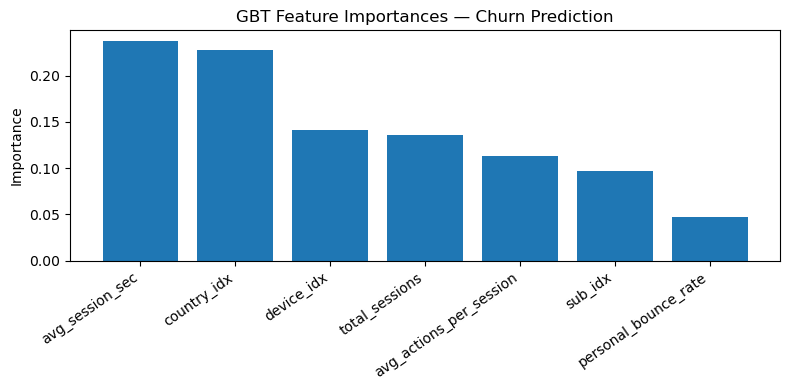

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from pyspark.ml.classification import GBTClassificationModel

# Locate both stages by type rather than by hardcoded index,
# so this cell remains correct if pipeline stages are ever added or reordered.
assembler_stage = next(s for s in model.stages if isinstance(s, VectorAssembler))
gbt_stage       = next(s for s in model.stages if isinstance(s, GBTClassificationModel))

feature_names = assembler_stage.getInputCols()
importances   = gbt_stage.featureImportances.toArray()

sorted_idx = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(len(importances)), importances[sorted_idx])
ax.set_xticks(range(len(importances)))
ax.set_xticklabels([feature_names[i] for i in sorted_idx], rotation=35, ha="right")
ax.set_title("GBT Feature Importances — Churn Prediction")
ax.set_ylabel("Importance")
plt.tight_layout()
plt.show()

### Layman Explanation

After training, we ask the model: **which inputs were most useful for predicting churn?**

The bar chart ranks every feature from most to least important. Features that appear near the top were leaned on most heavily when the model made its decisions.

**Important caveat for this dataset:** Because the model is near-random (AUC-ROC = 0.53), these importances do not mean the top features are *good* predictors of churn — they mean the GBT happened to split on those features most often. Think of it as ranking which clues a detective used in a case they ultimately got wrong. The rankings are still useful as hypotheses: `avg_session_sec` or `total_sessions` appearing near the top suggests that if any features could predict churn in a richer dataset, engagement depth would be the place to start — but the current data provides no confirmation that these signals are actually predictive.

### Technical Discussion

GBT feature importances are computed as the **normalised sum of impurity reductions** across all trees, weighted by the number of samples that flowed through each split:

```
importance(feature f) ∝ Σ_{trees} Σ_{splits on f} (impurity_before − impurity_after) × n_samples
```

The result is a `SparseVector` normalised so all importances sum to 1.0. It is accessed on the fitted `GBTClassificationModel` stage, which is located via `isinstance` lookup rather than a hardcoded index (e.g. `model.stages[-1]`) — this keeps the chart correct if stages are ever added or reordered in the pipeline.

Feature names are retrieved by locating the fitted `VectorAssembler` stage with the same `isinstance` pattern. `np.argsort(importances)[::-1]` produces indices in descending order, aligning bar positions and labels correctly.

**Reliability caveat:** With AUC-ROC at 0.53 (near random), the importances show which features the model *used most frequently for splitting*, but those splits did not produce meaningful class separation. High importance for a feature in a near-random model indicates the GBT found that feature had the most impurity to reduce — which in a 90/10 imbalanced dataset often just means the feature correlates weakly with the dominant class. The rankings should be treated as hypotheses for future feature engineering, not as validated predictors of churn.

### Terminology

| Term | Meaning |
|------|---------|
| **Feature importance** | A score assigned to each input variable indicating how much it contributed to the model's predictions. Higher = more useful. |
| **Impurity reduction** | The decrease in a node's impurity (e.g. Gini impurity or variance) after a split. A large reduction means the split cleanly separates classes. |
| **Gini impurity** | A measure of how mixed the class labels are at a tree node. A value of 0 means the node is pure (all one class); 0.5 means maximally mixed. |
| **Normalised importance** | Importances are rescaled so they sum to 1, enabling relative comparison across features. |
| **SparseVector** | A Spark data type for lists with many zero values, storing only non-zero entries for efficiency. |
| **`np.argsort`** | Returns the indices that would sort an array. Combined with `[::-1]` (reverse), it gives descending order. |

## Cell 7 — Confusion Matrix

In [7]:
cm = (
    predictions
    .groupBy("churned", "prediction")
    .count()
    .orderBy("churned", "prediction")
    .toPandas()
)

# Pivot to a proper 2×2 matrix so rows/columns match the visual layout
# described in the explanations above (actual vs predicted).
cm_pivot = (
    cm.pivot(index="churned", columns="prediction", values="count")
    .fillna(0)
    .astype(int)
)
cm_pivot.index.name   = "Actual \\ Predicted"
cm_pivot.columns.name = None
print("Confusion matrix (rows=actual, columns=predicted):")
print(cm_pivot.to_string())

Confusion matrix (rows=actual, columns=predicted):
                    0.0   1.0
Actual \ Predicted           
0                    12   174
1                     7  1796


### Layman Explanation

A confusion matrix is a **2×2 scoreboard** that counts how the model classified each user:

|  | Predicted: Retained | Predicted: Churned |
|--|--|--|
| **Actual: Retained** | Correctly left alone ✓ | False alarm — wasted re-engagement effort |
| **Actual: Churned** | Missed churn — lost user | Correctly flagged ✓ |

The off-diagonal cells are the errors. In a churn context, **missing a churner** (bottom-left) is usually more expensive than **falsely flagging a retained user** (top-right), because a missed churner means a lost customer.

**What this specific matrix is telling us:** The model predicted "retained" for only **19 out of 1,989** test users (12 + 7). In other words, it labelled 99% of all test users as churned regardless of their behaviour. This is the signature of a model that has learned the class distribution (90% churned) rather than any discriminating signal — it plays it safe by almost always guessing the majority class. The low false-negative count (7 missed churners) is not a sign of skill; it is a side effect of almost never predicting "retained" at all. Conversely, it correctly identifies only 12 out of 186 genuinely retained users — a retained-class recall of just 6.5%.

### Technical Discussion

The confusion matrix is computed with a Spark `groupBy` on `(churned, prediction)` followed by `.count()`. This is equivalent to a cross-tabulation. The result has at most four rows (one per cell of the 2×2 matrix).

- `churned=0, prediction=0` → **True Negatives (TN)**: correctly predicted retained.
- `churned=1, prediction=1` → **True Positives (TP)**: correctly predicted churned.
- `churned=0, prediction=1` → **False Positives (FP)**: incorrectly predicted churned (false alarm).
- `churned=1, prediction=0` → **False Negatives (FN)**: incorrectly predicted retained (missed churn).

From these four numbers, all classification metrics can be derived:
- Precision = TP / (TP + FP)
- Recall = TP / (TP + FN)
- F1 = 2 × Precision × Recall / (Precision + Recall)

**Analysis of the observed matrix (TN=12, FP=174, FN=7, TP=1796):**

The model predicted "retained" (class 0) for only 12 + 7 = **19 users** out of 1,989 in the test set. The remaining 1,970 were all predicted churned. This near-degenerate behaviour produces:

| Metric | Churned class | Retained class |
|--------|--------------|----------------|
| Precision | 1796 / 1970 = **91.2%** | 12 / 19 = 63.2% |
| Recall | 1796 / 1803 = **99.6%** | 12 / 186 = **6.5%** |

The retained-class recall of 6.5% is the clearest indicator of model failure: it correctly identifies only 12 of the 186 genuinely retained users. A random classifier would identify ~50%. The near-perfect churned-class recall (99.6%) is achieved trivially by predicting "churned" for almost everyone.

### Terminology

| Term | Meaning |
|------|---------|
| **Confusion matrix** | A table showing the count of correct and incorrect predictions for each class combination. |
| **True Positive (TP)** | Model correctly predicted the positive class (churned = 1). |
| **True Negative (TN)** | Model correctly predicted the negative class (retained = 0). |
| **False Positive (FP)** | Model predicted churned but user was actually retained. Also called a Type I error. |
| **False Negative (FN)** | Model predicted retained but user actually churned. Also called a Type II error. |
| **Precision** | Of everyone the model predicted as churned, what fraction truly churned? Penalises false alarms. |
| **Recall (Sensitivity)** | Of everyone who actually churned, what fraction did the model catch? Penalises missed churners. |
| **F1 score** | The harmonic mean of precision and recall — a single number balancing both concerns. |

## Cell 8 — Cleanup

In [8]:
predictions.unpersist()
test.unpersist()
spark.stop()
print("Spark session stopped.")

Spark session stopped.
